In [31]:
graphics_toolkit("gnuplot");

In [32]:
f=@(t,y) y./(t+2)+t.^2+2.*t;

In [33]:
function [t,y]=euler_method(f,interval,y0,h)
    t=interval(1):h:interval(2);
    y=zeros(size(t));
    y(1)=y0;
    for i=1:(length(t)-1)
        y(i+1)=y(i)+h*f(t(i),y(i));
    end
end

function [t,y]=euler_cauchy_method(f,interval,y0,h)
    t=interval(1):h:interval(2);
    y=zeros(size(t));
    y(1)=y0;
    for i=1:(length(t)-1)
        y_pred=y(i)+h*f(t(i), y(i));
        y(i+1)=y(i)+(h/2)*(f(t(i),y(i))+f(t(i+1),y_pred));
    end
end

function [t,y]=runge_kutta4(f,interval,y0,h)
    t=interval(1):h:interval(2);
    y=zeros(size(t));
    y(1)=y0;
    for i=1:(length(t)-1)
        k1=f(t(i),y(i));
        k2=f(t(i)+h/2,y(i)+h*k1/2);
        k3=f(t(i)+h/2,y(i)+h*k2/2);
        k4=f(t(i)+h,y(i)+h*k3);
        y(i+1)=y(i)+h/6*(k1+2*k2+2*k3+k4);
    end
end

In [34]:
t0=-1;
T=0;
y0=1.5;
h=0.1;
t=t0:h:T;
y_exact=(t.^3)/2+t.^2+t+2;

[t_euler,y_euler]=euler_method(f,[t0,T],y0,h);
[t_cauchy,y_cauchy]=euler_cauchy_method(f,[t0,T],y0,h);
[t_rk4,y_rk4]=runge_kutta4(f,[t0,T],y0,h);

err_euler=max(abs(y_exact-y_euler));
err_cauchy=max(abs(y_exact-y_cauchy));
err_rk4=max(abs(y_exact-y_rk4));

y_euler
y_cauchy
y_rk4

fprintf('Погрешность метода Эйлера: %e\n',err_euler);
fprintf('Погрешность метода Эйлера-Коши: %e\n',err_cauchy);
fprintf('Погрешность метода Рунге-Кутта 4: %e\n',err_rk4);

















y_euler =

 Columns 1 through 8:

   1.5000   1.5500   1.5919   1.6286   1.6628   1.6976   1.7358   1.7803

 Columns 9 through 11:

   1.8340   1.8999   1.9809


y_cauchy =

 Columns 1 through 8:

   1.5000   1.5460   1.5849   1.6198   1.6536   1.6894   1.7302   1.7789

 Columns 9 through 11:

   1.8387   1.9124   2.0031


y_rk4 =

 Columns 1 through 8:

   1.5000   1.5455   1.5840   1.6185   1.6520   1.6875   1.7280   1.7765

 Columns 9 through 11:

   1.8360   1.9095   2.0000



Погрешность метода Эйлера: 1.911601e-02

Погрешность метода Эйлера-Коши: 3.055344e-03

Погрешность метода Рунге-Кутта 4: 1.694239e-06


In [35]:
h2=0.2;

[t_euler2,y_euler2]=euler_method(f,[t0,T],y0,h2);
[t_cauchy2,y_cauchy2]=euler_cauchy_method(f,[t0,T],y0,h2);
[t_rk42,y_rk42]=runge_kutta4(f,[t0,T],y0,h2);

y_euler2
y_cauchy2
y_rk42

y_euler_h_double=y_euler(1:2:end)
y_cauchy_h_double=y_cauchy(1:2:end)
y_rk4_h_double=y_rk4(1:2:end)

p_euler=1;
p_cauchy=2;
p_rk4=4;

runge_euler=max(abs(y_euler_h_double-y_euler2))/(2^p_euler-1);
runge_cauchy=max(abs(y_cauchy_h_double-y_cauchy2))/(2^p_cauchy-1);
runge_rk4=max(abs(y_rk4_h_double-y_rk42))/(2^p_rk4-1);

fprintf('\nПогрешность по правилу Рунге:\n');
fprintf('Метод Эйлера (p=1): %e\n',runge_euler);
fprintf('Метод Эйлера-Коши (p=2): %e\n',runge_cauchy);
fprintf('Метод Рунге-Кутта 4 (p=4): %e\n',runge_rk4);








y_euler2 =

   1.5000   1.6000   1.6747   1.7459   1.8361   1.9682


y_cauchy2 =

   1.5000   1.5873   1.6582   1.7366   1.8465   2.0121


y_rk42 =

   1.5000   1.5840   1.6520   1.7280   1.8360   2.0000



y_euler_h_double =

   1.5000   1.5919   1.6628   1.7358   1.8340   1.9809


y_cauchy_h_double =

   1.5000   1.5849   1.6536   1.7302   1.8387   2.0031


y_rk4_h_double =

   1.5000   1.5840   1.6520   1.7280   1.8360   2.0000












Погрешность по правилу Рунге:

Метод Эйлера (p=1): 1.272526e-02

Метод Эйлера-Коши (p=2): 3.009391e-03

Метод Рунге-Кутта 4 (p=4): 1.622470e-06


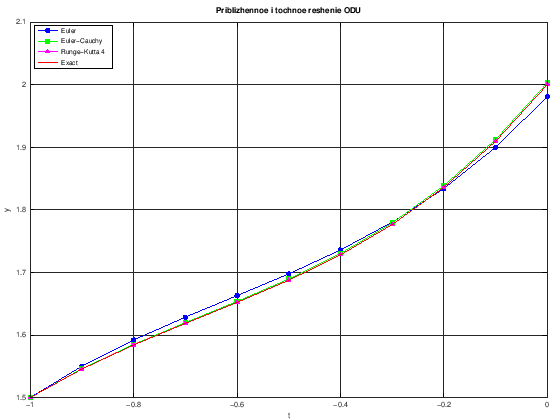

In [36]:
figure;
plot(t_euler,y_euler,'b-o','LineWidth',1.2,'MarkerSize',4,'MarkerFaceColor','b'); hold on;
plot(t_cauchy,y_cauchy,'g-s','LineWidth',1.2,'MarkerSize',4,'MarkerFaceColor','g');
plot(t_rk4,y_rk4,'m-^','LineWidth',1.2,'MarkerSize',4,'MarkerFaceColor','m');
plot(t,y_exact,'r-','LineWidth',2);
grid on;
xlabel('t');
ylabel('y');
title('Priblizhennoe i tochnoe reshenie ODU');
legend('Euler','Euler-Cauchy','Runge-Kutta 4','Exact','Location','northwest');
hold off;



t =

 Columns 1 through 8:

   -1.0000   -0.9000   -0.8000   -0.7000   -0.6000   -0.5000   -0.4000   -0.3000

 Columns 9 through 11:

   -0.2000   -0.1000         0












t_double =

  -1.0000  -0.8000  -0.6000  -0.4000  -0.2000        0











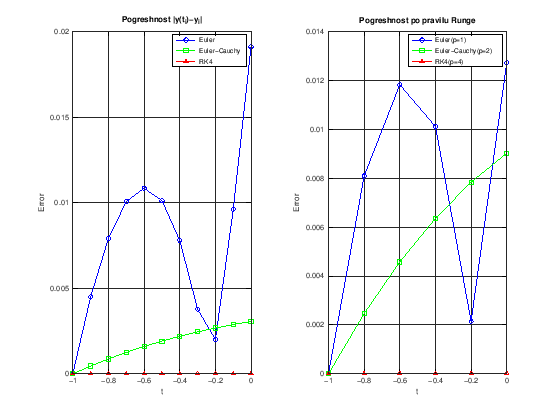

In [37]:
subplot(1,2,1);
t
plot(t,abs(y_exact-y_euler),'b-o','LineWidth',1.2,'MarkerSize',4); hold on;
plot(t,abs(y_exact-y_cauchy),'g-s','LineWidth',1.2,'MarkerSize',4);
plot(t,abs(y_exact-y_rk4),'r-^','LineWidth',1.2,'MarkerSize',4);
grid on;
xlabel('t');
ylabel('Error');
title('Pogreshnost |y(t_i)-y_i|');
legend('Euler','Euler-Cauchy','RK4','Location','northeast');

subplot(1,2,2);
t_double=t(1:2:end)
plot(t_double,abs(y_euler_h_double-y_euler2),'b-o','LineWidth',1.2,'MarkerSize',4); hold on;
plot(t_double,abs(y_cauchy_h_double-y_cauchy2),'g-s','LineWidth',1.2,'MarkerSize',4);
plot(t_double,abs(y_rk4_h_double-y_rk42),'r-^','LineWidth',1.2,'MarkerSize',4);
grid on;
xlabel('t');
ylabel('Error');
title('Pogreshnost po pravilu Runge');
legend('Euler(p=1)','Euler-Cauchy(p=2)','RK4(p=4)','Location','northeast');